In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

In [4]:
# 모델정의
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN,self).__init__()
        
        self.conv1 = nn.Conv2d(1,10,kernel_size=5)
        self.conv2 = nn.Conv2d(10,20,kernel_size=5)
        self.fc1 = nn.Linear(320,50)
        self.fc2 = nn.Linear(50,10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x),2))
        x = F.relu(F.max_pool2d(self.conv2(x),2))

        x = x.view(-1,320)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x,dim=1)

In [5]:
# 2. 모델 인스턴스 생성 및 파라미터 저장
model_to_save = SimpleCNN()
print(model_to_save)

SimpleCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [ ]:
path = 'cnn_model_statedict.pth'
torch.save(model_to_save.state_dict(), path)
# svae오 문제생길수 있음:용량,디렉토리

In [ ]:
# state_dict
for i,key in enumerate(model_to_save.state_dict()):
    if i >= 2 : break
    print(key)

conv1.weight
conv1.bias


In [10]:
# state_dict
for i,key in enumerate(model_to_save.state_dict()):
    # if i >= 2 : break
    print(key)

conv1.weight
conv1.bias
conv2.weight
conv2.bias
fc1.weight
fc1.bias
fc2.weight
fc2.bias


In [ ]:
# 3.저장한 파라미터를 로딩
# 허깅페이스등 사이트에서 성능좋고 작은 모델들 있음, 거기서 불러와야함
# 3.1 로딩할 파라미터를 담을 그릇으로 동일 구조의 모델 객체를 생성
model_to_load = SimpleCNN()

try: # 오류발생때문에 파일처리할때는 try처리 해야함
    # 3.2 state_dict 파일 로딩
    state_dict = torch.load(path,weights_only=True) # 파라미터를 로딩

    # 3.3 model_to_load loading
    model_to_load.load_state_dict(state_dict)
    print(f'Model state_dict loaded from {path}')

except Exception as e:

    print(f'Error: {e}') 


Model state dict loaded from cnn_model_statedict.pth


In [ ]:
# 로딩하는 주목적: 추론하기 위해서
# 추론:예측값 뽑아낼려고
# forward  - loss - backward - step
# 학습:loss 까지만
# 추론:순전파 까지만 , eval mode로 바꾸기

In [ ]:
# 두 모델의 파라미터가 동일한지 확인
# 1.평가모드로 설정
model_to_load.eval()


# model_to_save의 conv1의 가중치 추출
weight_saved = model_to_save.conv1.weight.data
# model_to_load의 conv1의 가중치 추출
weight_loaded = model_to_load.conv1.weight.data # weight를 층마다 추출 가능함~~~!

# 두개 가중치 비교
are_equal = torch.equal(weight_saved,weight_loaded)
print(f'Are the weights of conv1 in both models equal? {are_equal}') # 쓸모가 있으니 꼭 외우기!!!!!!

Are the weights of conv1 in both models equal? True


In [20]:
# 전체모델 저장 및 로드
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN,self).__init__()

        self.conv1=nn.Conv2d(1,10,kernel_size=5)

        self.conv2=nn.Conv2d(10,20,kernel_size=5)
        self.fc1 = nn.Linear(320,50)
        self.fc2 = nn.Linear(50,10)

    def forward(self,x):
        x = F.relu(F.maxpool2d(self.conv1(x),2))
        x = F.relu(F.maxpool2d(self.conv2(x),2))
        x = x.view(-1,320)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
# 1.모델 오브젝트 생성 및 전체 모델 저장
model_to_save = SimpleCNN()
path = 'cnn_model_full.pth'
torch.save(model_to_save, path)
print(f'Full model object saved to {path}')


Full model object saved to cnn_model_full.pth


In [ ]:
# 2. 전체모델 로드
model_loaded = torch.load(path) # 로드하면 오브젝트다
print(model_loaded) # 앞으로 로드를 많이 해야함 , 단 검증된 로드를

SimpleCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [ ]:
# 3.훈련 재개를 위한 체크포인트 저장 및 로드
model = SimpleCNN() # 모델 생성
optimizer = optim.SGD(model.parameters(),lr=0.001,momentum=0.9) # 확률절 경사하강법

# 가상의 훈련 정보(5번째 에폭을 마친 상태라고 가정)
EPOCH  = 5
LOSS = 0.4
# PATH = 'model_checkpoint.tar' # tar.파일을 여러개를 묶은것
# PATH = 'model_checkpoint_{datatime}_{LOSS}_{EPOCH}.path' # tar.파일을 여러개를 묶은것
PATH = 'model_checkpoint.path' 

# 1. 체크포인트 저장
torch.save({
    'epoch':EPOCH,
    'model_state_dict':model.state_dict(),
    'optimizer_state_dict':optimizer.state_dict(),
    'loss':LOSS # 이렇게 일일이 save에 저장해야함
},PATH)


In [ ]:
# 체크포인트 로드를 위한 새로운 모델, 옵티마이저 생성
model_to_load = SimpleCNN()
optimizer_to_load = optim.SGD(model_to_load.parameters(),lr=0.01)

# lr 추출
# print(optimizer_to_load.param_groups[0])
print(optimizer_to_load.param_groups[0]['lr']) # lr만 뽑고 싶을때
# optimizer: w를 가지고 있어야해


0.01


In [30]:
# 체크포인트 로드
checkpoint = torch.load(PATH)
# modle_to_load setting
model_to_load.load_state_dict(checkpoint['model_state_dict']) # model_state_dict : 키
optimizer_to_load.load_state_dict(checkpoint['optimizer_state_dict'])

epoch_loaded = checkpoint['epoch']
loss_loaded=checkpoint['loss']

In [31]:
print(optimizer_to_load.param_groups[0]['lr'])

0.001


Computation device selected: cuda
Starting training for 100 epochs...


Epoch 1/100 | Train Loss: 0.2103 | Val Loss: 0.0698 | Val Acc: 97.69%
  -> Validation loss decreased (inf --> 0.0698). Saving model to 'best_model_checkpoint.pth'...


Epoch 2/100 | Train Loss: 0.0664 | Val Loss: 0.0424 | Val Acc: 98.68%
  -> Validation loss decreased (0.0698 --> 0.0424). Saving model to 'best_model_checkpoint.pth'...


Epoch 3/100 | Train Loss: 0.0488 | Val Loss: 0.0408 | Val Acc: 98.66%
  -> Validation loss decreased (0.0424 --> 0.0408). Saving model to 'best_model_checkpoint.pth'...


Epoch 4/100 | Train Loss: 0.0392 | Val Loss: 0.0378 | Val Acc: 98.76%
  -> Validation loss decreased (0.0408 --> 0.0378). Saving model to 'best_model_checkpoint.pth'...


...

Epoch 96/100 | Train Loss: 0.0018 | Val Loss: 0.1085 | Val Acc: 98.96%


Epoch 97/100 | Train Loss: 0.0032 | Val Loss: 0.1150 | Val Acc: 98.98%


Epoch 98/100 | Train Loss: 0.0020 | Val Loss: 0.1348 | Val Acc: 98.89%


Epoch 99/100 | Train Loss: 0.0033 | Val Loss: 0.1271 | Val Acc: 98.92%


Epoch 100/100 | Train Loss: 0.0034 | Val Loss: 0.1490 | Val Acc: 98.96%

Finished Training!


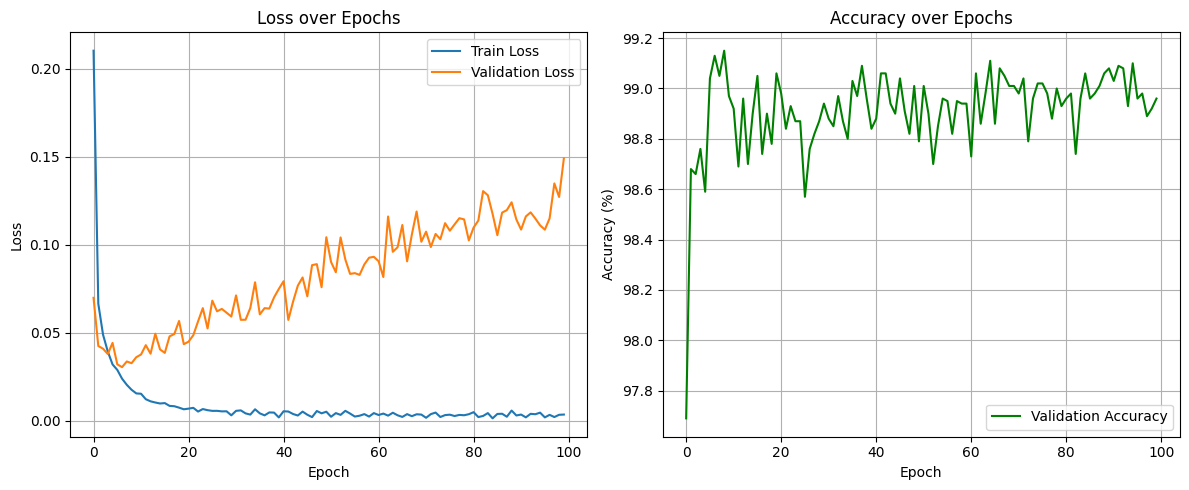


Loading the best model for verification...
Loaded model from epoch 7 with loss 0.0304 and accuracy 99.13%


In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os


# 1. 설정 및 장치 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Computation device selected: {device}")


# 2. 데이터셋 준비 (MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


# 훈련 데이터
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, num_workers=2,pin_memory=True)


# 검증(테스트) 데이터 - 여기서는 Test 셋을 Validation 용도로 사용합니다.
validation_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
validation_loader = DataLoader(dataset=validation_dataset, batch_size=1000, shuffle=False, num_workers=2,pin_memory=True)


# 3. 모델 정의 (SimpleCNN)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.relu2 = nn.ReLU()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)


    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# 모델, 손실함수, 옵티마이저 초기화
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# 4. 헬퍼 함수 정의 (Train/Test Step)
def train_step(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    # 진행 상황 표시를 위해 tqdm 사용 (leave=False로 에폭마다 줄 바꿈 방지)
    for images, labels in tqdm(data_loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
       
        outputs = model(images)
        loss = loss_fn(outputs, labels)
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
       
        total_loss += loss.item()
    return total_loss / len(data_loader)


def validate_step(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
   
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
           
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
           
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
           
    avg_loss = total_loss / len(data_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# 5. 메인 학습 루프 (요청하신 로직 적용)
num_epochs = 100  # 시간 관계상 10으로 설정 (원하시는 대로 50으로 변경 가능)
                  # 일단 100으로 설정
best_vloss = float('inf') # 최저 검증 손실 초기화


train_losses = []
val_losses = []
val_accuracies = []


print(f"Starting training for {num_epochs} epochs...")


for epoch in range(num_epochs):
    # --- 훈련 루프 ---
    avg_train_loss = train_step(model, train_loader, criterion, optimizer, device)
   
    # --- 검증 루프 ---
    avg_vloss, avg_vacc = validate_step(model, validation_loader, criterion, device)
   
    # 기록 저장
    train_losses.append(avg_train_loss)
    val_losses.append(avg_vloss)
    val_accuracies.append(avg_vacc)
   
    # 결과 출력
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_vloss:.4f} | Val Acc: {avg_vacc:.2f}%")


    # --- 체크포인트 저장 로직 ---
    # 현재 검증 손실이 역대 최저이면 체크포인트 저장
    if avg_vloss < best_vloss:
        print(f"  -> Validation loss decreased ({best_vloss:.4f} --> {avg_vloss:.4f}). Saving model to 'best_model_checkpoint.pth'...")
        best_vloss = avg_vloss
       
        # 모델 저장
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_vloss,
            'accuracy': avg_vacc
        }, 'best_model_checkpoint.pth')


print("\nFinished Training!")


# 6. 결과 시각화
plt.figure(figsize=(12, 5))


# 손실 그래프
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)


# 정확도 그래프
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()


# 7. 저장된 베스트 모델 불러오기 테스트
print("\nLoading the best model for verification...")
checkpoint = torch.load('best_model_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1} with loss {checkpoint['loss']:.4f} and accuracy {checkpoint['accuracy']:.2f}%")

# Epoc끝날때마다 step 값 조절함
# 원래 시간 19분 

In [ ]:

# 정리: 과정합 방지하는 4가지 방법
# 이 코드 이유:pytorch는 early-stopping 없어서 이렇게 코드 짜야함
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os


# 1. 설정 및 장치 확인
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Computation device selected: {device}")
BATCH_SIZE = 64
TEST_BATCH_SIZE = 1000
EPOCHS = 50  # 충분히 큰 에폭 설정 (Early Stopping으로 조기 종료될 것임)
LEARNING_RATE = 0.001
PATIENCE = 5 # Early Stopping을 위한 인내값 (5번 동안 성능 향상 없으면 종료)
             # 5번까지 참겠다!!!


# 2. 데이터셋 준비 (MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)


validation_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
validation_loader = DataLoader(dataset=validation_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=2)


# 3. 모델 정의 (Dropout 추가) - [해결책 2: Dropout]
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.relu1 = nn.ReLU()
       
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.relu2 = nn.ReLU()
       
        # 드롭아웃 레이어 추가 (50% 확률로 뉴런 비활성화)
        # dropout된 넘이 영원히 dropout 되는건 아니다.
        self.dropout = nn.Dropout(p=0.5)
       
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)


    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 320)
       
        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Fully Connected Layer 사이에 드롭아웃 적용
        x = self.fc2(x)
        return x


model = ImprovedCNN().to(device)


# 4. 손실함수 및 옵티마이저 (Weight Decay 추가) - [해결책 3: L2 Regularization]
criterion = nn.CrossEntropyLoss()
# weight_decay=1e-4 추가하여 가중치가 너무 커지는 것을 방지
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) 
# 아주작은값으로 주기(학습을 안정화 시킴)
# 1e-4는 학습 파라미터




# 5. 학습률 스케줄러 추가 - [해결책 4: Scheduler]
# 5 에폭마다 학습률을 0.5배로 감소
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


# 6. 학습 및 검증 함수
def train_step(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(data_loader)


def validate_step(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return total_loss / len(data_loader), 100 * correct / total


# 7. 메인 학습 루프 (Early Stopping 적용) - [해결책 1: Early Stopping]
best_vloss = float('inf')
patience_counter = 0
train_losses, val_losses, val_accuracies = [], [], []


print(f"Starting training with Early Stopping (Patience={PATIENCE})...")


for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_step(model, validation_loader, criterion, device)
   
    # 스케줄러 업데이트
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()
   
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
   
    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.5f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
   
    # Early Stopping 로직
    if val_loss < best_vloss:
        best_vloss = val_loss
        patience_counter = 0 # 카운터 초기화
        torch.save(model.state_dict(), 'best_model.pth') # 최고로 좋은모델만 저장
        print(f"  -> Best model saved (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early Stopping Triggered! Training stopped.")
            break # 바깥에for 문에 대한 break

print("\nFinished Training!")


Computation device selected: cuda
Starting training with Early Stopping (Patience=5)...
Epoch 1/50 | LR: 0.00100 | Train Loss: 0.3897 | Val Loss: 0.0683 | Val Acc: 97.84%
  -> Best model saved (Val Loss: 0.0683)
Epoch 2/50 | LR: 0.00100 | Train Loss: 0.1514 | Val Loss: 0.0479 | Val Acc: 98.47%
  -> Best model saved (Val Loss: 0.0479)
Epoch 3/50 | LR: 0.00100 | Train Loss: 0.1138 | Val Loss: 0.0421 | Val Acc: 98.79%
  -> Best model saved (Val Loss: 0.0421)
Epoch 4/50 | LR: 0.00100 | Train Loss: 0.0924 | Val Loss: 0.0333 | Val Acc: 99.00%
  -> Best model saved (Val Loss: 0.0333)
Epoch 5/50 | LR: 0.00100 | Train Loss: 0.0817 | Val Loss: 0.0308 | Val Acc: 98.94%
  -> Best model saved (Val Loss: 0.0308)
Epoch 6/50 | LR: 0.00050 | Train Loss: 0.0623 | Val Loss: 0.0282 | Val Acc: 99.09%
  -> Best model saved (Val Loss: 0.0282)
Epoch 7/50 | LR: 0.00050 | Train Loss: 0.0565 | Val Loss: 0.0272 | Val Acc: 99.20%
  -> Best model saved (Val Loss: 0.0272)
Epoch 8/50 | LR: 0.00050 | Train Loss: 0.053

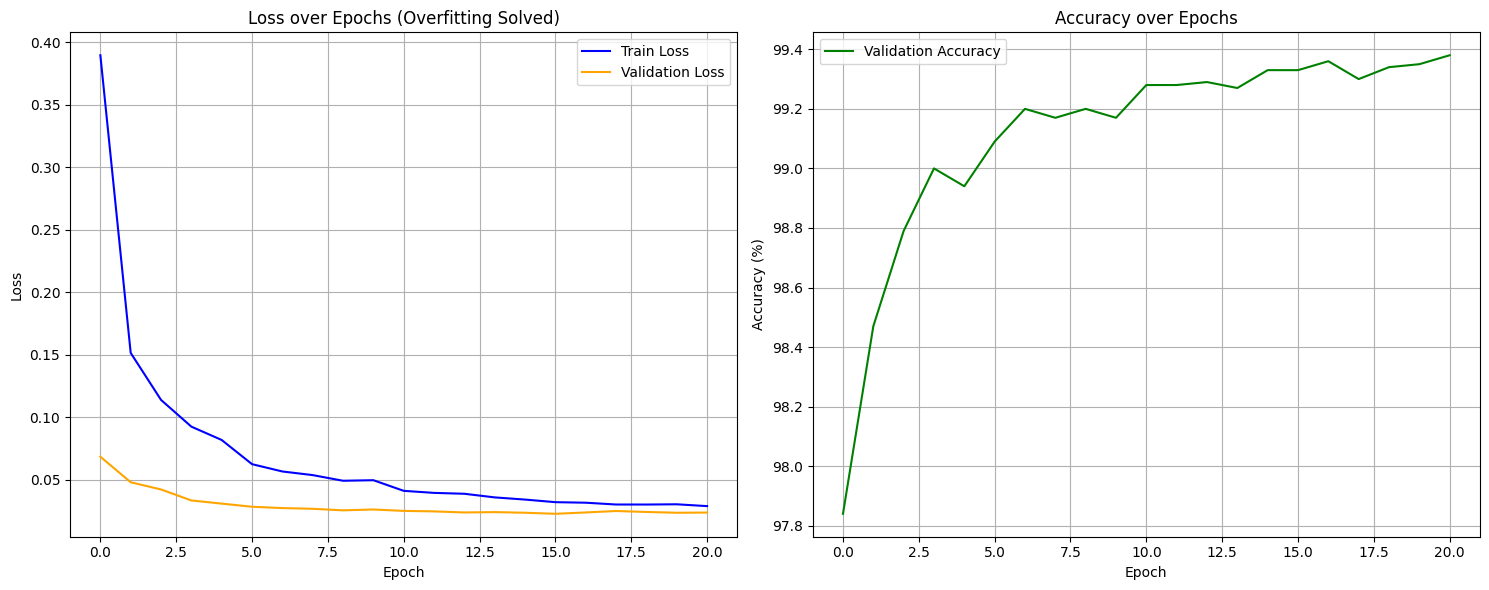


Best model loaded successfully!
Final Test Accuracy (Best Model): 99.33%


In [34]:
# ... (앞선 학습 코드 이후)


# 8. 결과 시각화
plt.figure(figsize=(15, 6))


# 1) 손실(Loss) 그래프
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Loss over Epochs (Overfitting Solved)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


# 2) 정확도(Accuracy) 그래프
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()


# 9. 저장된 베스트 모델 불러오기 및 확인
if os.path.exists('best_model.pth'):
    best_model = ImprovedCNN().to(device)
    best_model.load_state_dict(torch.load('best_model.pth'))
    print("\nBest model loaded successfully!")
   
    # 베스트 모델로 최종 평가
    final_loss, final_acc = validate_step(best_model, validation_loader, criterion, device)
    print(f"Final Test Accuracy (Best Model): {final_acc:.2f}%")
